# TP 6 — Q-learning tabulaire sur un *gridworld*

> Support théorique : [cours_apprentissage_par_renforcement.md](cours_apprentissage_par_renforcement.md).

**Objectif.** Implémenter, en NumPy pur et hors ligne, un **MDP** simple (un labyrinthe en grille) puis un
agent **Q-learning** (module 6, §5). On observera la courbe d'apprentissage, la **politique apprise**, et
l'effet de l'**exploration** (ε-greedy). Aucune dépendance externe : l'environnement est écrit à la main.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
print("Prêt.")

Prêt.


## 1. L'environnement : un gridworld 4×4

- Départ en haut à gauche (état 0), objectif en bas à droite (état 15, récompense **+1**).
- Un **piège** (état 5, récompense **−1**). Départ et piège/objectif sont terminaux.
- Chaque pas coûte **−0,04** (pour encourager les chemins courts).
- 4 actions : 0=haut, 1=droite, 2=bas, 3=gauche. Sortir de la grille = rester sur place.

C'est un **MDP** (module 6, §2) : états, actions, dynamique (ici déterministe), récompense et un facteur
d'actualisation γ que l'agent devra exploiter.

In [2]:
TAILLE = 4
N_ETATS = TAILLE * TAILLE
N_ACTIONS = 4
DEPART, OBJECTIF, PIEGE = 0, 15, 5
NOMS_ACTIONS = ["↑", "→", "↓", "←"]

def pas(s, a):
    """Renvoie (etat_suivant, recompense, termine)."""
    ligne, col = divmod(s, TAILLE)
    if a == 0: ligne -= 1
    elif a == 1: col += 1
    elif a == 2: ligne += 1
    elif a == 3: col -= 1
    ligne = min(max(ligne, 0), TAILLE - 1)   # rester dans la grille
    col = min(max(col, 0), TAILLE - 1)
    s2 = ligne * TAILLE + col
    if s2 == OBJECTIF:
        return s2, 1.0, True
    if s2 == PIEGE:
        return s2, -1.0, True
    return s2, -0.04, False

# Contrôle de cohérence de l'environnement
assert pas(14, 1) == (OBJECTIF, 1.0, True)     # depuis 14, aller à droite -> objectif
assert pas(1, 2) == (PIEGE, -1.0, True)         # depuis 1, descendre -> piège (état 5)
assert pas(0, 0)[0] == 0                          # monter depuis le coin -> reste sur place
print("Environnement valide.")

Environnement valide.


## 2. Entraînement par Q-learning

On maintient une table `Q[état, action]` et on applique la mise à jour du module 6, §5.3 :

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma \max_{a'} Q(s',a') - Q(s,a)\,]$$

Les actions sont choisies en **ε-greedy** : au hasard avec probabilité ε (exploration), sinon la meilleure
connue (exploitation).

In [3]:
def entrainer(episodes=3000, alpha=0.1, gamma=0.95, epsilon=0.1, max_pas=50, graine=0):
    rng_local = np.random.default_rng(graine)
    Q = np.zeros((N_ETATS, N_ACTIONS))
    retours = []
    for _ in range(episodes):
        s, termine, total, etapes = DEPART, False, 0.0, 0
        while not termine and etapes < max_pas:
            if rng_local.random() < epsilon:
                a = int(rng_local.integers(N_ACTIONS))       # exploration
            else:
                a = int(np.argmax(Q[s]))                      # exploitation
            s2, r, termine = pas(s, a)
            cible = r if termine else r + gamma * Q[s2].max()
            Q[s, a] += alpha * (cible - Q[s, a])
            s, total, etapes = s2, total + r, etapes + 1
        retours.append(total)
    return Q, np.array(retours)

Q, retours = entrainer()
debut = retours[:100].mean()
fin = retours[-100:].mean()
print(f"Retour moyen — 100 premiers épisodes : {debut:.3f}")
print(f"Retour moyen — 100 derniers épisodes : {fin:.3f}")
assert fin > debut, "l'agent doit s'améliorer au fil des épisodes" 

Retour moyen — 100 premiers épisodes : 0.571
Retour moyen — 100 derniers épisodes : 0.723


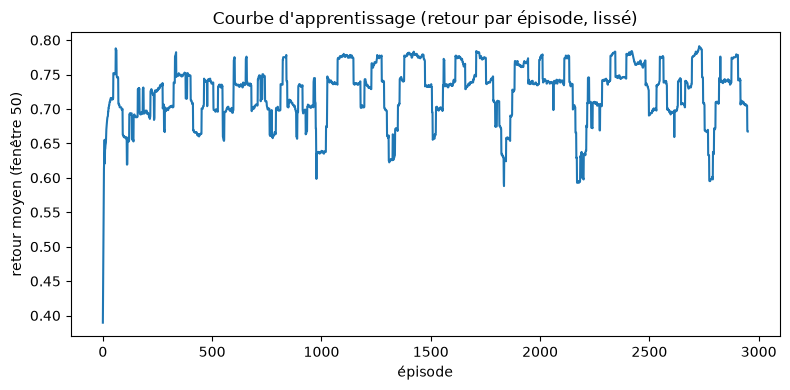

In [4]:
# Courbe d'apprentissage lissée (moyenne glissante)
fenetre = 50
lisse = np.convolve(retours, np.ones(fenetre) / fenetre, mode="valid")
plt.figure(figsize=(8, 4))
plt.plot(lisse)
plt.title("Courbe d'apprentissage (retour par épisode, lissé)")
plt.xlabel("épisode")
plt.ylabel(f"retour moyen (fenêtre {fenetre})")
plt.tight_layout()
plt.show()

## 3. La politique apprise

La politique **greedy** prend, dans chaque état, l'action de plus grand Q (module 6, §3.2). On l'affiche
sur la grille, puis on vérifie qu'en partant du départ elle atteint bien l'objectif sans tomber dans le
piège.

In [5]:
politique = np.argmax(Q, axis=1)
grille = []
for s in range(N_ETATS):
    if s == OBJECTIF: grille.append(" G ")
    elif s == PIEGE:  grille.append(" X ")
    else:             grille.append(f" {NOMS_ACTIONS[politique[s]]} ")
print("Politique apprise (G=objectif, X=piège) :")
for ligne in range(TAILLE):
    print("".join(grille[ligne * TAILLE:(ligne + 1) * TAILLE]))

# Dérouler la politique greedy depuis le départ
s, chemin, termine, etapes = DEPART, [DEPART], False, 0
while not termine and etapes < 50:
    s, _, termine = pas(s, int(politique[s]))
    chemin.append(s)
    etapes += 1
print("\nChemin suivi :", chemin)
assert chemin[-1] == OBJECTIF, "la politique greedy doit atteindre l'objectif"
assert PIEGE not in chemin, "elle doit éviter le piège"
print("-> l'agent rejoint l'objectif en évitant le piège.")

Politique apprise (G=objectif, X=piège) :
 →  →  →  ↓ 
 ↓  X  →  ↓ 
 ↓  ↓  →  ↓ 
 →  →  →  G 

Chemin suivi : [0, 1, 2, 3, 7, 11, 15]
-> l'agent rejoint l'objectif en évitant le piège.


## 4. Pourquoi explorer ? Comparaison à une politique aléatoire

L'agent entraîné doit largement dépasser une **baseline aléatoire** (module 6, §8.3). C'est le minimum
attendu : sans apprentissage, l'agent erre et tombe souvent dans le piège ou épuise son budget de pas.

In [6]:
def retour_moyen(politique_fn, episodes=500, max_pas=50, graine=1):
    rng_local = np.random.default_rng(graine)
    total = 0.0
    for _ in range(episodes):
        s, termine, etapes = DEPART, False, 0
        while not termine and etapes < max_pas:
            a = politique_fn(s, rng_local)
            s, r, termine = pas(s, a)
            total += r
            etapes += 1
    return total / episodes

retour_aleatoire = retour_moyen(lambda s, rl: int(rl.integers(N_ACTIONS)))
retour_appris = retour_moyen(lambda s, rl: int(np.argmax(Q[s])))
print(f"Retour moyen — politique aléatoire : {retour_aleatoire:.3f}")
print(f"Retour moyen — politique apprise   : {retour_appris:.3f}")
assert retour_appris > retour_aleatoire, "la politique apprise doit battre le hasard"
print("-> l'apprentissage apporte un gain net face à l'exploration aveugle.")

Retour moyen — politique aléatoire : -1.172
Retour moyen — politique apprise   : 0.800
-> l'apprentissage apporte un gain net face à l'exploration aveugle.


## 5. Exercice guidé — la sélection ε-greedy

Écrivez `choisir_action(Q, s, epsilon, rng)` : avec probabilité `epsilon`, une action aléatoire
(exploration) ; sinon l'action de plus grand Q (exploitation). **Critères de réussite** : avec
`epsilon=0`, la fonction est purement greedy ; avec `epsilon=1`, elle finit par couvrir toutes les actions.

In [7]:
def choisir_action(Q, s, epsilon, rng):
    # TODO : si rng.random() < epsilon -> action aléatoire ; sinon -> argmax(Q[s])
    raise NotImplementedError("À compléter")

# Décommentez pour tester :
# Qd = np.array([[0.0, 9.0, 0.0, 0.0]])   # action 1 clairement meilleure
# assert choisir_action(Qd, 0, 0.0, np.random.default_rng(0)) == 1
# tirages = {choisir_action(Qd, 0, 1.0, np.random.default_rng(k)) for k in range(50)}
# assert tirages == {0, 1, 2, 3}

### Solution

In [8]:
def choisir_action(Q, s, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(Q.shape[1]))     # exploration
    return int(np.argmax(Q[s]))                    # exploitation

Qd = np.array([[0.0, 9.0, 0.0, 0.0]])              # action 1 = meilleure
assert choisir_action(Qd, 0, 0.0, np.random.default_rng(0)) == 1, "epsilon=0 -> greedy"
tirages = {choisir_action(Qd, 0, 1.0, np.random.default_rng(k)) for k in range(50)}
assert tirages == {0, 1, 2, 3}, "epsilon=1 -> explore toutes les actions"
print("OK : ε=0 est greedy, ε=1 explore l'ensemble des actions.")

OK : ε=0 est greedy, ε=1 explore l'ensemble des actions.


## Récapitulatif

- Un **MDP** se résume à états, actions, dynamique, récompense et facteur d'actualisation γ.
- Le **Q-learning** apprend la valeur des actions par la mise à jour de Bellman, sans modèle de la dynamique.
- L'**ε-greedy** arbitre exploration et exploitation ; sans exploration, l'agent peut stagner.
- On évalue **toujours** face à une baseline (ici, le hasard) et on rapporterait plusieurs graines
  (module 6, §8.3), le RL étant très variable.

⚠️ Ce labyrinthe est un jouet déterministe. Sur un vrai problème, méfiez-vous du *reward hacking*
(module 6, §8.1) et bornez l'exploration risquée.

Suite : [Module 7 — MLOps & mise en production](../07_mlops_production/cours_mlops_production.md).